In [ ]:
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
!tar -xzvf ta-lib-0.4.0-src.tar.gz
%cd ta-lib
!./configure --prefix=/usr
!make
!make install
!pip install Ta-Lib

--2024-12-26 06:31:28--  http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
Resolving prdownloads.sourceforge.net (prdownloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:c95, ...
Connecting to prdownloads.sourceforge.net (prdownloads.sourceforge.net)|104.18.13.149|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2024-12-26 06:31:29--  http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving downloads.sourceforge.net (downloads.sourceforge.net)... 104.18.12.149, 104.18.13.149, 2606:4700::6812:d95, ...
Reusing existing connection to prdownloads.sourceforge.net:80.
HTTP request sent, awaiting response... 302 Found
Location: http://psychz.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz?viasf=1 [following]
--2024-12-26 06:31:29--  http://psychz.dl.sourcefo

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import talib as ta
import warnings
from sklearn.model_selection import GridSearchCV
warnings.filterwarnings('ignore')

In [ ]:
ticker = 'BTC-USD'
sequence_length = 60
train_ratio = 0.8

In [ ]:
btc_data = yf.download(ticker, start='2015-01-01', end='2024-01-01')
btc_data.columns = btc_data.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


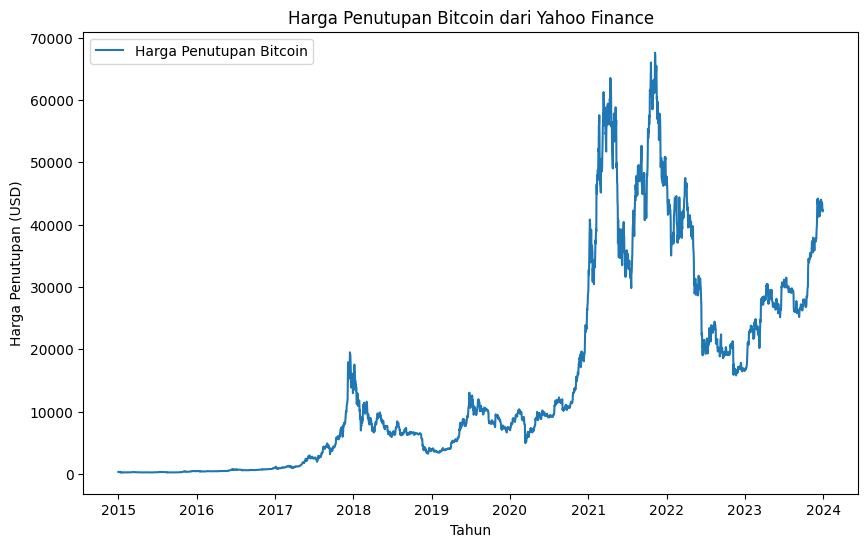

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(btc_data['Close'], label='Harga Penutupan Bitcoin')
plt.title('Harga Penutupan Bitcoin dari Yahoo Finance')
plt.xlabel('Tahun')
plt.ylabel('Harga Penutupan (USD)')
plt.legend()
plt.show()

In [ ]:
btc_data['EMA'] = ta.EMA(btc_data['Close'], timeperiod=100)
btc_data['MA'] = ta.SMA(btc_data['Close'], timeperiod=200)

In [ ]:
btc_data = btc_data.dropna()
data_to_scale = btc_data[['Close', 'EMA', 'MA']]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_to_scale)

In [ ]:
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

In [ ]:
training_data_len = int(np.ceil(train_ratio * len(scaled_data)))
train_data = scaled_data[:training_data_len]
test_data = scaled_data[training_data_len - sequence_length:]

In [ ]:
X_train, y_train = create_dataset(train_data, sequence_length)
X_test, y_test = create_dataset(test_data, sequence_length)

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [ ]:
# Define parameter grid for Grid Search
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Create KNN model
knn = KNeighborsRegressor()

# Create Grid Search
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Train model with Grid Search
grid_search.fit(X_train, y_train)

# Print best parameters
print(f'Best parameters found: {grid_search.best_params_}')
print(f'Best score: {-grid_search.best_score_}')

Best parameters found: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best score: 0.022613467290000317


In [ ]:
# Use the best model
best_knn_model = grid_search.best_estimator_

# Predict prices
predicted_prices = best_knn_model.predict(X_test)
predicted_prices_extended = np.zeros((predicted_prices.shape[0], 3))
predicted_prices_extended[:, 0] = predicted_prices
predicted_prices_original_scale = scaler.inverse_transform(predicted_prices_extended)[:, 0]

# Reverse scale y_test
y_test_extended = np.zeros((y_test.shape[0], 3))
y_test_extended[:, 0] = y_test
y_test_actual_original_scale = scaler.inverse_transform(y_test_extended)[:, 0]

# Calculate metrics
mse = mean_squared_error(y_test_actual_original_scale, predicted_prices_original_scale)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual_original_scale, predicted_prices_original_scale)
mape = mean_absolute_percentage_error(y_test_actual_original_scale, predicted_prices_original_scale)
accuracy = 100 - (mape * 100)

print(f'Akurasi: {accuracy:.2f}%')
print(f'MAPE: {mape * 100:.2f}%')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')

Akurasi: 26.22%
MAPE: 73.78%
Mean Squared Error (MSE): 345826723.99770796
Root Mean Squared Error (RMSE): 18596.416966655375
Mean Absolute Error (MAE): 17754.17065477547


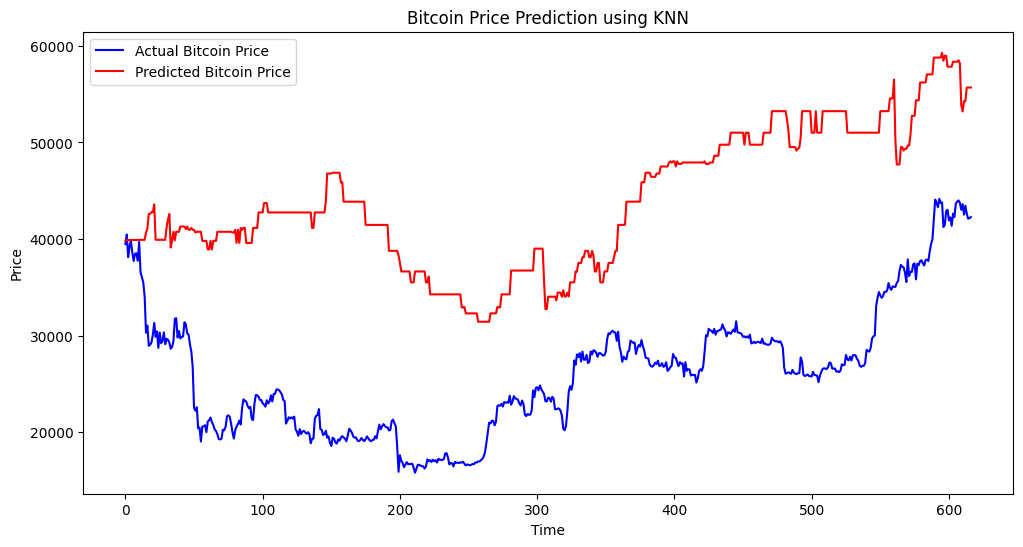

In [ ]:
# Plot the predictions
plt.figure(figsize=(12,6))
plt.plot(y_test_actual_original_scale, color='blue', label='Actual Bitcoin Price')
plt.plot(predicted_prices_original_scale, color='red', label='Predicted Bitcoin Price')
plt.title('Bitcoin Price Prediction using KNN')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

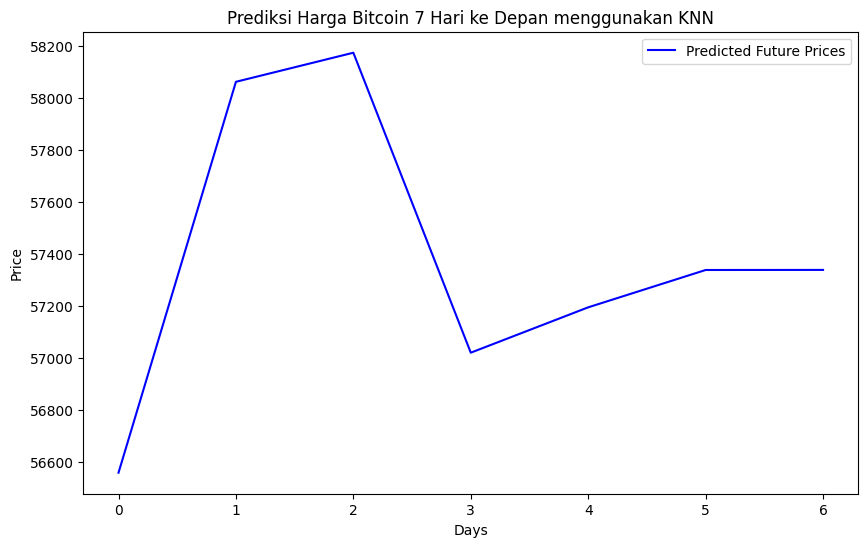

In [ ]:
# Future predictions
last_sequence = scaled_data[-sequence_length:]
future_predictions = []
num_days_to_predict = 7

for _ in range(num_days_to_predict):
    if len(last_sequence.shape) == 2:
        last_sequence = last_sequence.reshape(1, -1)
    predicted_price = best_knn_model.predict(last_sequence)
    future_predictions.append(predicted_price[0])
    predicted_price_with_features = np.zeros((1, scaled_data.shape[1]))
    predicted_price_with_features[0, 0] = predicted_price[0]
    last_sequence = np.concatenate((last_sequence[:, scaled_data.shape[1]:], predicted_price_with_features), axis=1)

future_predictions_scaled = np.array(future_predictions).reshape(-1, 1)
future_predictions_scaled_extended = np.zeros((future_predictions_scaled.shape[0], 3))
future_predictions_scaled_extended[:, 0] = future_predictions_scaled[:, 0]
future_predictions_original = scaler.inverse_transform(future_predictions_scaled_extended)[:, 0]

plt.figure(figsize=(10, 6))
plt.plot(future_predictions_original, label='Predicted Future Prices', color='blue')
plt.title('Prediksi Harga Bitcoin 7 Hari ke Depan menggunakan KNN')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
import joblib

# Save the best model
filename = 'best_knn_model.pkl'
joblib.dump(best_knn_model, filename)
print(f'Model saved as {filename}')

Model saved as best_knn_model.pkl


In [ ]:
from google.colab import files

files.download('best_knn_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>